# Limit density of the eigenvalues distribution
In this notebook we check that the logic to compute the stieltjes transform is correct. We do that by recovering the density from the stieltjes transform, and comparing that with a sample.  

In [2]:
from typing import Callable
from gpy_test.lag_window import lag_window
from statsmodels.tsa.arima_process import arma_generate_sample
import numpy as np
from gpy_test.covariance import _m  # limit stieltjes transform
from gpy_test.config.fixed_point import FixedPointConfig
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


def inversion_stieltjes(
    s: Callable[[complex], complex], epsilon: float = 1e-6
) -> callable:
    """
    Compute the absolutely continuous density part of the stieltjes transform s.
    """
    return lambda x: np.imag(s(x + 1j * epsilon)) / np.pi

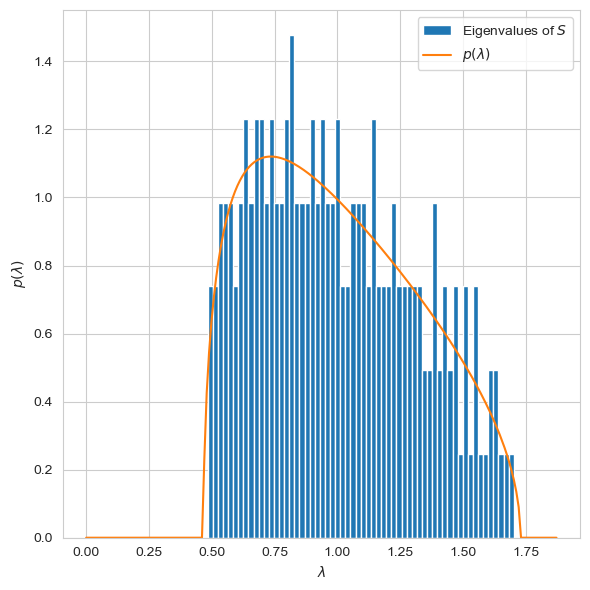

In [3]:
# generate a multi-dimensional time series. Each series is an ARMA(1,1) process, independent with the other time series.
M = 200  # dimension of the time series
N = 2000  # number of samples

# Generate an ARMA time series. By assumption it must be the same for all the time series in order to use the GPY test.
ar = 0
ma = 0
real = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
imag = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
y = real + 1j * imag

# compute the sample covariance matrix and the corresponding eigenvalues
S = (1 / N) * y.conj().T @ y
eigs = np.linalg.eigvalsh(S)

# estimate the spectral density using the lag window estimator
spectral_density = lambda nu: np.mean(lag_window(y, L=5)(nu))
frequency_grid = np.linspace(-0.5, 0.5, 100)
sd_values = np.array([spectral_density(f) for f in frequency_grid])
inverse_sd_values = 1 / sd_values
c = M / N

# define the limit density using the fixed point algorithm
fixed_point = FixedPointConfig(
    init_m_real=1,
    init_m_imag=1,
    max_steps=10,
    tolerance=1e-2,
)
m = lambda z: _m(z, inverse_sd_values, frequency_grid, c, fixed_point)
density = inversion_stieltjes(m)

# plot the density against the distribution of eigenvalues of S
SIZE_FIG = 6
fig, ax = plt.subplots(figsize=(SIZE_FIG, SIZE_FIG))
ax.hist(eigs, bins=60, density=True, label="Eigenvalues of $S$")
x = np.linspace(0, np.max(eigs) * 1.1, 200)
ax.plot(x, [density(xi) for xi in x], label=r"$p(\lambda)$")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$p(\lambda)$")
ax.legend()
fig.tight_layout()

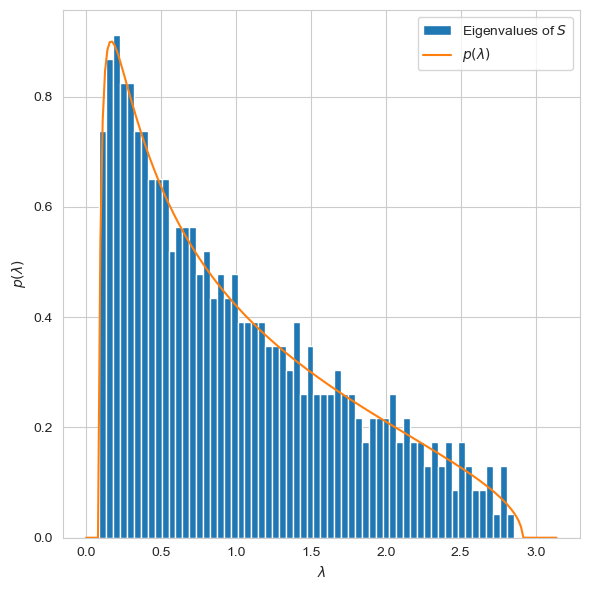

In [4]:
# generate a multi-dimensional time series. Each series is an ARMA(1,1) process, independent with the other time series.
M = 500  # dimension of the time series
N = 1000  # number of samples

# Generate an ARMA time series. By assumption it must be the same for all the time series in order to use the GPY test.
ar = 0
ma = 0
real = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
imag = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
y = real + 1j * imag

# compute the sample covariance matrix and the corresponding eigenvalues
S = (1 / N) * y.conj().T @ y
eigs = np.linalg.eigvalsh(S)

# estimate the spectral density using the lag window estimator
spectral_density = lambda nu: np.mean(lag_window(y, L=5)(nu))
frequency_grid = np.linspace(-0.5, 0.5, 100)
sd_values = np.array([spectral_density(f) for f in frequency_grid])
inverse_sd_values = 1 / sd_values
c = M / N

# define the limit density using the fixed point algorithm
fixed_point = FixedPointConfig(
    init_m_real=1,
    init_m_imag=1,
    max_steps=10,
    tolerance=1e-2,
)
m = lambda z: _m(z, inverse_sd_values, frequency_grid, c, fixed_point)
density = inversion_stieltjes(m)

# plot the density against the distribution of eigenvalues of S
SIZE_FIG = 6
fig, ax = plt.subplots(figsize=(SIZE_FIG, SIZE_FIG))
ax.hist(eigs, bins=60, density=True, label="Eigenvalues of $S$")
x = np.linspace(0, np.max(eigs) * 1.1, 200)
ax.plot(x, [density(xi) for xi in x], label=r"$p(\lambda)$")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$p(\lambda)$")
ax.legend()
fig.tight_layout()

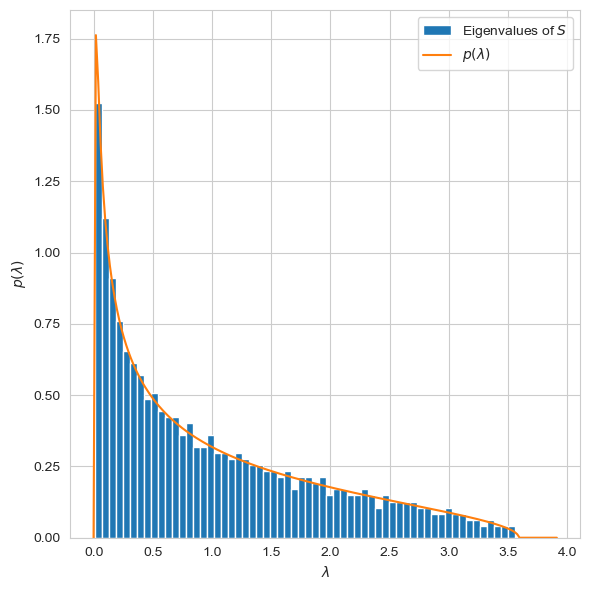

In [6]:
# generate a multi-dimensional time series. Each series is an ARMA(1,1) process, independent with the other time series.
M = 800  # dimension of the time series
N = 1000  # number of samples

# Generate an ARMA time series. By assumption it must be the same for all the time series in order to use the GPY test.
ar = 0.8
ma = -0.8
real = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
imag = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
y = real + 1j * imag

# compute the sample covariance matrix and the corresponding eigenvalues
S = (1 / N) * y.conj().T @ y
eigs = np.linalg.eigvalsh(S)

# estimate the spectral density using the lag window estimator
spectral_density = lambda nu: np.mean(lag_window(y, L=5)(nu))
frequency_grid = np.linspace(-0.5, 0.5, 100)
sd_values = np.array([spectral_density(f) for f in frequency_grid])
inverse_sd_values = 1 / sd_values
c = M / N

# define the limit density using the fixed point algorithm
fixed_point = FixedPointConfig(
    init_m_real=1,
    init_m_imag=1,
    max_steps=100,
    tolerance=1e-2,
)
m = lambda z: _m(z, inverse_sd_values, frequency_grid, c, fixed_point)
density = inversion_stieltjes(m)

# plot the density against the distribution of eigenvalues of S
SIZE_FIG = 6
fig, ax = plt.subplots(figsize=(SIZE_FIG, SIZE_FIG))
ax.hist(eigs, bins=60, density=True, label="Eigenvalues of $S$")
x = np.linspace(0, np.max(eigs) * 1.1, 200)
ax.plot(x, [density(xi) for xi in x], label=r"$p(\lambda)$")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$p(\lambda)$")
ax.legend()
fig.tight_layout()